In [1]:

# why multi-head is better than single-head ? 

# https://gemini.google.com/app/8720e969a2fcbae5
# The Averaging Bottleneck (Single Head)
# Representation Subspaces (Multi-Head)
# The Computational Equivalence

# too many heads:
#   Dot-product discriminability collapses: In a d_head-dimensional random projection, the variance of the dot product between two vectors scales with d_head, When d_head gets very small, there just isn't enough room for queries/keys to be pushed far apart in angle — random or near-random keys start looking similar to a query, so the softmax degenerates toward uniform, You get noise-induced averaging, which is the same symptom you were trying to escape (uniform attention), just caused by insufficient dimensionality instead of a forced single softmax.
#   Johnson–Lindenstrauss-style capacity limit. To keep pairwise angular relationships between N distinguishable concepts roughly preserved under a linear projection, you need roughly d_head = O(log N / ε²) dimensions. Below that, key vectors for genuinely different tokens start colliding in the projected space — the head physically cannot keep enough patterns separable   


# pay-off curve = inverted-U
# 
# performance
    # ^
    # |         ____________
    # |       /              \___
    # |      /                    \___
    # |     /                          \
    # |    /
    # |   /
    # +--+---------------------------------> h (num heads, d_head = d_model/h)
    #    1    few heads    "sweet spot"    many tiny heads
    #    (averaging       (diverse, still  (noisy dot products,
    #     bottleneck)      well-powered)    redundant/collapsing heads)
#  


# Multi-head splitting trades a combinatorial bottleneck (can't represent multiple relations at once) for a dimensionality/statistical 
# bottleneck (each relation is represented too weakly to be reliably distinguished). The optimum sits where you've captured most of the 
# useful "different relation types need different heads" benefit before dot-product signal-to-noise per head starts degrading — empirically, 
# that's around d_head ≈ 64–128 for typical model/vocab scales, largely independent of total model size.


#---
# implement YaRN for positinal encodings, QK norm

# MHA: num_query_heads == num_kv_heads
# GQA: 1 < num_kv_heads < num_query_heads and num_query_heads % num_kv_heads == 0
# MQA: num_kv_heads == 1


# TODO:

# line-by-line explaination of this script, weight init method used, RoPE rewrite, compute graph vis, tensor health check, attentino map vis
# make a report on: SHA/MQA/GQA/MHA performance/cost 
# report benchmark: cached vs. uncached decode latency as sequence length grows

In [ ]:
# TODO: 
# No mixed precision or torch.compile. Add bf16 autocast

In [1]:
import time
import json

# ! will NEED PyTorch version 2.5+ --> for scaled_dot_product_attention(enable_gqa=True)
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Optional, Tuple
from einops import rearrange

from model_config import ModelConfig, AttentionConfig
import training_engine as training_engine 
from tensor_tools import init_custom_weight
from inference_engine import advanced_inference, load_model_weights
from kv_cache import KV_cache


device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Device:         {device}")
print(f"PyTorch:        {torch.__version__}")

if torch.cuda.is_available():
    print(f"GPU:            {torch.cuda.get_device_name(0)}")
    print(f"CUDA version:   {torch.version.cuda}")

    print(f"device capability: {torch.cuda.get_device_capability()}")
    print(f"flash_attention_available: {torch.backends.cuda.is_flash_attention_available()}")


Device:         cuda
PyTorch:        2.8.0+cu129
GPU:            NVIDIA GeForce GTX 1660 Ti
CUDA version:   12.9
device capability: (7, 5)
flash_attention_available: False


In [2]:

configs = ModelConfig(

    model_name="level2_attention_models",
    tied_embeddings=False,  
    
    embed_dim=2**5,   # 32
    vocab_size=2**11,  # 2048
    max_context_window=2**6,   # 64
    max_training_batch_size=2**4,   # 16
    learning_rate=1e-3,
    num_layers=5,

    attention=AttentionConfig(
        num_q_heads=2**0,  # 1 | 1   x   x    x
        num_kv_heads=2**0, # 1 | 1   1   2+   x
        rope_theta= 10000.0,
    ),

    ffn=None,

    save_path="../models/level2_attention_models.pt",
    val_loss_history="../models/level2_attention_models_val_loss_history.txt",

    checkpoint_dir= "../checkpoints/",
    checkpoint_every_steps= 250,
    keep_last_n_checkpoints= 3,

)

print(configs)

ModelConfig(model_name='level2_attention_models', tied_embeddings=False, max_training_batch_size=16, embed_dim=32, vocab_size=2048, max_context_window=64, num_layers=5, learning_rate=0.001, attention=AttentionConfig(num_q_heads=1, num_kv_heads=1, rope_theta=10000.0), ffn=None, save_path='../models/level2_attention_models.pt', val_loss_history='../models/level2_attention_models_val_loss_history.txt', checkpoint_dir='../checkpoints/', checkpoint_every_steps=250, keep_last_n_checkpoints=3)


In [ ]:
class RotaryEmbedding(nn.Module):

    def __init__(self, cfg:ModelConfig):
        super().__init__()

        base     = cfg.attention.rope_theta
        head_dim = cfg.embed_dim // cfg.attention.num_q_heads


        # shape: [head_dim // 2]
        inv_freq = 1.0 / (
            base ** (torch.arange(0, head_dim, 2).float() / head_dim)
        ).to(dtype=torch.float32)
        
        self.register_buffer("inv_freq", inv_freq, persistent=False)


    def forward(
            self,
            position_ids: torch.Tensor,   # [B, seq] or [seq]
            dtype= torch.float32,
        ) -> tuple[torch.Tensor, torch.Tensor]:
            """position_ids: [B, T] (or [T]) -> cos, sin of shape [B, 1, T, head_dim]"""

            if position_ids.dim() == 1:
                position_ids = position_ids.unsqueeze(0)          # [1, seq]


            # position_ids: [B, seq]  (integer)
            # inv_freq:     [head_dim//2]
            # freqs:        [B, seq, head_dim//2]
            freqs = torch.einsum(
                "bi,j->bij",
                position_ids.to(dtype=self.inv_freq.dtype),
                self.inv_freq,
            )

            emb = torch.cat((freqs, freqs), dim=-1) # [B, seq, head_dim]

            # broadcast over the head dimension → [B, 1, seq, head_dim]
            return emb.cos().to(dtype).unsqueeze(1), emb.sin().to(dtype).unsqueeze(1)


def rotate_half(x: torch.Tensor) -> torch.Tensor:
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat((-x2, x1), dim=-1)


def apply_rotary_pos_emb(
    q:   torch.Tensor,
    k:   torch.Tensor,
    cos: torch.Tensor,
    sin: torch.Tensor,
) -> Tuple[torch.Tensor, torch.Tensor]:
    
    cos = cos.to(device=q.device, dtype=q.dtype)
    sin = sin.to(device=q.device, dtype=q.dtype)

    q = (q * cos) + (rotate_half(q) * sin)
    k = (k * cos) + (rotate_half(k) * sin)
    return q, k

In [ ]:
class Attention_SubBlock(nn.Module):

    def __init__(self, cfg:ModelConfig):
        super().__init__()

        self.embed_dim    = cfg.embed_dim
        self.num_q_heads  = cfg.attention.num_q_heads
        self.num_kv_heads = cfg.attention.num_kv_heads
        self.num_layers   = cfg.num_layers
        
        if self.embed_dim % self.num_q_heads != 0:
            raise ValueError("embed_dim must be divisible by num_q_heads")
        if self.num_q_heads % self.num_kv_heads != 0:
            raise ValueError("num_q_heads must be divisible by num_kv_heads")

        self.head_dim = self.embed_dim // self.num_q_heads
        self.q_dim    = self.num_q_heads * self.head_dim
        self.kv_dim   = self.num_kv_heads * self.head_dim

        # ONE matrix for Q, K and V: columns are [ q | k | v ]
        self.W_qkv = nn.Parameter(torch.empty(self.embed_dim, self.q_dim + 2 * self.kv_dim))
        self.W_o   = nn.Parameter(torch.empty(self.q_dim, self.embed_dim))

        self.init_params()



    def init_params(self):

        q_end = self.q_dim
        k_end = q_end + self.kv_dim

        W_q = self.W_qkv[:, :q_end]
        W_k = self.W_qkv[:, q_end:k_end]
        W_v = self.W_qkv[:, k_end:]

        init_custom_weight(W_q, is_residual_output=False)
        init_custom_weight(W_k, is_residual_output=False)
        init_custom_weight(W_v, is_residual_output=False)

        # Residual output projection (scaled by depth)
        init_custom_weight(self.W_o, 
                           is_residual_output=True, 
                           num_layers=self.num_layers)



    def forward(
        self,
        x:   torch.Tensor,
        cos: torch.Tensor,          # [B, 1, seq, head_dim] – already computed
        sin: torch.Tensor,
        cache: Optional[KV_cache] = None,
        layer_idx: int = 0,
        
        lane_ids:  Optional[torch.Tensor] = None,
        attn_mask: Optional[torch.Tensor] = None,   # [B, 1, T, kv_len] bool, from cache.prepare()
   
    ) -> torch.Tensor:

        batch_size, seq_len, embed_dim = x.shape

        qkv = x @ self.W_qkv  # [B, T, q_dim + 2*kv_dim]
        q, k, v = qkv.split([self.q_dim, self.kv_dim, self.kv_dim], dim=-1)


        q = rearrange(q, 
                      "batch_size seq_len (num_q_heads head_dim)" 
                      " -> " 
                      "batch_size num_q_heads seq_len head_dim", 
                      num_q_heads=self.num_q_heads)
        
        k = rearrange(k, 
                      "batch_size seq_len (num_kv_heads head_dim)" 
                      " -> " 
                      "batch_size num_kv_heads seq_len head_dim",
                      num_kv_heads=self.num_kv_heads)
        
        v = rearrange(v, 
                      "batch_size seq_len (num_kv_heads head_dim)" 
                      " -> " 
                      "batch_size num_kv_heads seq_len head_dim",
                      num_kv_heads=self.num_kv_heads)


        q, k = apply_rotary_pos_emb(q, k, cos, sin)


        if cache is not None:
            k, v = cache.update(layer_idx, lane_ids, k, v)



        # The mask rule is that a query at absolute position p may attend to a key at 
        # absolute position a iff p - W < a <= p. The <= p part is causality, 
        # and the > p - W part is the sliding window. 
        out = F.scaled_dot_product_attention(
            q, k, v,
            attn_mask=attn_mask,
            is_causal=(attn_mask is None), # fast path only when no mask is given
            enable_gqa=(self.num_q_heads != self.num_kv_heads),
        )


        # Merge attention heads
        out = rearrange(
            out,
            "batch_size num_q_heads seq_len head_dim"
            " -> " 
            "batch_size seq_len (num_q_heads head_dim)",
        )


        return out @ self.W_o


In [5]:
class Level_2_Transformer_Block(nn.Module):
    def __init__(self, cfg:ModelConfig):
        super().__init__()
        self.attention_sub_block = Attention_SubBlock(cfg)
        self.norm = nn.RMSNorm(cfg.embed_dim)


    def forward(
        self,
        x: torch.Tensor,
        cos: torch.Tensor,
        sin: torch.Tensor,
        cache: Optional[KV_cache] = None,
        layer_idx: int = 0,

        lane_ids =None, 
        attn_mask=None

    ) -> torch.Tensor:
        
        residual = x
        
        x = self.norm(x)

        x = self.attention_sub_block(
            x, 
            cos, 
            sin, 
            cache=cache, 
            layer_idx=layer_idx,
            lane_ids=lane_ids, 
            attn_mask=attn_mask,
        )

        return  x + residual


In [ ]:
class Level2_Model(nn.Module):

    def __init__(self, cfg:ModelConfig):
        super().__init__()

        self.vocab_size = cfg.vocab_size
        self.embed_dim  = cfg.embed_dim  

        self.tied_embeddings = cfg.tied_embeddings      


        self.embed  = nn.Parameter(torch.empty(self.vocab_size, self.embed_dim))
        
        if not self.tied_embeddings:
            self.unembed = nn.Parameter(torch.empty(self.embed_dim, self.vocab_size))


        self.rotary = RotaryEmbedding(cfg)

        self.layers = nn.ModuleList([Level_2_Transformer_Block(cfg) 
                                     for _ in range(cfg.num_layers)
                                    ])

        self.final_rms_norm = nn.RMSNorm(cfg.embed_dim)


        self.init_params()



    def init_params(self):
        init_custom_weight(self.embed,   is_residual_output=False)
        
        if not self.tied_embeddings:
            init_custom_weight(self.unembed, is_residual_output=False)


    def forward(
            self, 
            input_ids: torch.Tensor, 
            cache: Optional[KV_cache] = None,
            lane_ids: Optional[torch.Tensor] = None,  # which cache lane each batch row uses
            attn_mask=None, # attn_mask only used without cache (tests)
    ) -> torch.Tensor:

        batch_size, seq_len = input_ids.shape

        device = input_ids.device # from the data, never a global
        # print('input_ids.device -> ', input_ids.device)

        # [batch_size, seq_len] -> [batch_size, seq_len, embed_dim]
        x = self.embed[input_ids] 



        if cache is None:
            position_ids = torch.arange(seq_len, device=device).expand(batch_size, -1)
            # attn_mask stays whatever the caller passed (None -> is_causal fast path)
        else:
            if lane_ids is None:
                lane_ids = torch.arange(batch_size, device=device)
            position_ids, attn_mask = cache.prepare(lane_ids, seq_len)


        cos, sin = self.rotary(position_ids, dtype=x.dtype)


        
        for i, layer in enumerate(self.layers):
                x = layer(x, 
                          cos, 
                          sin, 
                          cache=cache, 
                          layer_idx=i,
                          lane_ids=lane_ids,
                          attn_mask=attn_mask,
                        )        

        if cache is not None:
            cache.commit(lane_ids, seq_len) # once, after ALL layers


        x = self.final_rms_norm(x)


        if self.tied_embeddings:
            return x @ self.embed.T                    # [B, T, V]
        
        return x @ self.unembed
    

Step 0000 | train(avg) 7.6295 | val 7.6292 | val ppl 2057.41 | lr 2.00e-05
Step 0050 | train(avg) 7.5939 | val 7.5707 | val ppl 1940.50 | lr 5.20e-04
Step 0100 | train(avg) 7.2116 | val 7.1697 | val ppl 1299.45 | lr 1.00e-03
Step 0150 | train(avg) 6.9952 | val 6.9643 | val ppl 1058.13 | lr 9.99e-04
Step 0200 | train(avg) 6.7313 | val 6.6784 | val ppl 795.01 | lr 9.97e-04
Checkpoint saved: ..\checkpoints\level2_attention_models_step00000250.pt
Step 0250 | train(avg) 6.3167 | val 6.2482 | val ppl 517.10 | lr 9.94e-04
Step 0300 | train(avg) 5.9432 | val 5.9017 | val ppl 365.66 | lr 9.89e-04
Step 0350 | train(avg) 5.6842 | val 5.6426 | val ppl 282.20 | lr 9.83e-04
Step 0400 | train(avg) 5.4886 | val 5.4315 | val ppl 228.48 | lr 9.76e-04
Step 0450 | train(avg) 5.2964 | val 5.2707 | val ppl 194.56 | lr 9.68e-04
Checkpoint saved: ..\checkpoints\level2_attention_models_step00000500.pt
Step 0500 | train(avg) 5.1762 | val 5.1403 | val ppl 170.77 | lr 9.58e-04
Step 0550 | train(avg) 5.1038 | val 

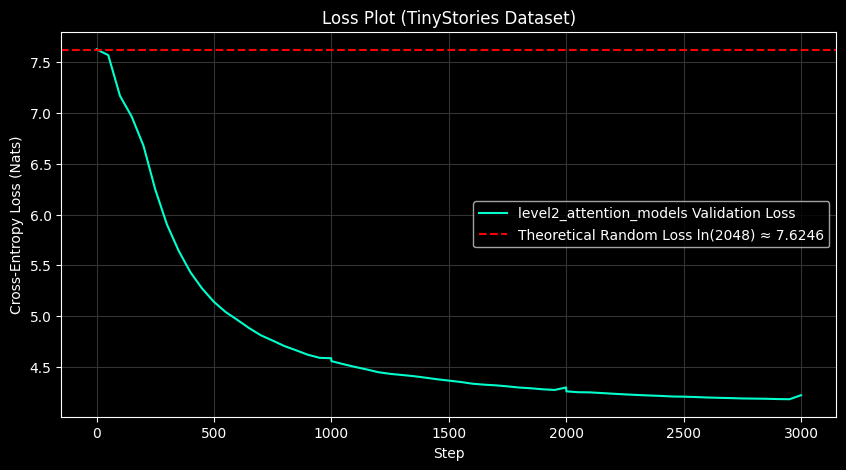

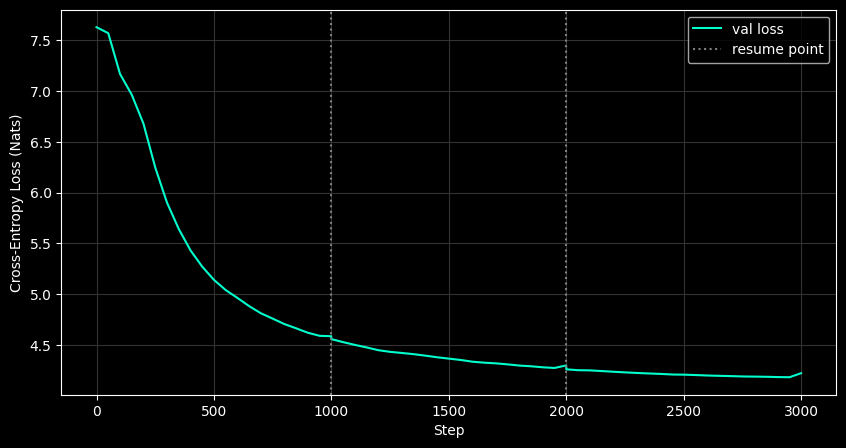

Max memory allocated: 0.06 GB


In [ ]:
TOTAL_STEPS = 3000 # the WHOLE planned run, across all stages


# Same schedule args in every stage (see the LR section below)
sched = dict(schedule_total_steps=TOTAL_STEPS, warmup_steps=100, min_lr_ratio=0.1)

# Clean slate: remove stale checkpoints from earlier experiments,
# otherwise resume_from="latest" could pick one of them up later
for p in training_engine.list_checkpoints(configs):
    p.unlink()





seed = 42
torch.manual_seed(seed)
model = Level2_Model(configs)
# Compile the model
# model = torch.compile(model)          # default mode = "default"


training_engine.train_and_save_model(
    model, configs, device, 1000, seed=seed, **sched
)




model = Level2_Model(configs)

training_engine.train_and_save_model(
    model, configs, device, 2000, seed=seed, resume_from="latest", **sched
)




model = Level2_Model(configs)

training_engine.train_and_save_model(
    model, configs, device, 3000, seed=seed, resume_from="latest", **sched
)


training_engine.plot_loss_history(configs)





# small blip at steps 999, 1999 and 2999. The last evaluation of each stage uses the full validation set, while the others use 20 batches
import matplotlib.pyplot as plt

rows = [l.strip().split(",") for l in open(configs.val_loss_history) if l.strip()]
steps, losses = [int(s) for s, _ in rows], [float(v) for _, v in rows]

plt.style.use("dark_background")
plt.figure(figsize=(10, 5))
plt.plot(steps, losses, color="#00FFCC", label="val loss")
for boundary in (1000, 2000):
    plt.axvline(boundary, color="gray", linestyle=":", label="resume point" if boundary == 1000 else None)
plt.xlabel("Step"); plt.ylabel("Cross-Entropy Loss (Nats)")
plt.grid(True, color="#333333"); plt.legend(); plt.show()




# if torch.cuda.is_available():
#     max_mem_bytes = torch.cuda.max_memory_allocated()
#     max_mem_gb = max_mem_bytes / (1024 ** 3)
#     print(f"Max memory allocated: {max_mem_gb:.2f} GB")


In [8]:

# Load the JSON file
with open("2048-tokenizer.json", "r", encoding="utf-8") as f:
    tokenizer_data = json.load(f)
eos_token_id = tokenizer_data.get("special_tokens", {}).get("<|endoftext|>")


model = load_model_weights(
    Level2_Model(configs),
    configs.save_path,
    device,
)

prompt_strs = [
    "write a story about",
    "write like a little boy that was angry",
    "write as a little boy that was happy,",
    "my name is ",
] 



results = advanced_inference(
    model=model, 
    configs=configs,
    prompt_strs=prompt_strs,
    device=device, 
    max_new_tokens=500,     # far beyond max_context_window=64: fine
    max_KV_lanes=2, 
    chunk_size=16, 
    eos_token_id=eos_token_id,
)

for r in results:
    print("---" * 20); print(r.text, f"[{r.finish_reason}]")

[INFO] Loaded weights from ..\models\level2_attention_models.pt (151,744 parameters)
------------------------------------------------------------
write a story about and said, "Let's go home." Ben thought for a moment and said, "Hello, kids, but you should not be careful you for me?" Sam said, "Yes, you can be friends. I love you for your friend and the boy goose, but it is better to pen too. One day she said he is too fast and funny. He had never forever.
 [eos]
------------------------------------------------------------
write like a little boy that was angry. She says, "Yes, I can't make you doing?" They all said, "We are youry arm up, you don't want to give you?" Lily asked, and they all played together every day.
 [eos]
------------------------------------------------------------
write as a little boy that was happy," and a new toy car with something hard and said, "Hello, bird," Ben said. "It's okay! Can I help you?" Lily said.
 [eos]
---------------------------------------------

In [ ]:
# TODO: continue training from checkpoint, save opt state &...


# model = load_model_weights(
#     Level2_Model(configs),
#     configs.save_path,
#     device,
# )



In [ ]:
@pytest.mark.parametrize("chunk", [1, 3, 8, 13])
@torch.no_grad()
def test_cache_matches_full_forward(chunk, W=8):
    cfg = tiny_cfg(max_context_window=W, num_q_heads=4, num_kv_heads=2)  # exercise GQA
    model = Level2_Model(cfg).eval()
    ids = torch.randint(0, cfg.vocab_size, (1, 40))
    T = ids.shape[1]
    i = torch.arange(T)
    mask = (i[None] <= i[:, None]) & (i[None] > i[:, None] - W)
    ref = model(ids, attn_mask=mask[None, None])

    cache = KV_cache(cfg, num_lanes=1, device="cpu")
    lane = torch.tensor([0])
    out = torch.cat([model(ids[:, s:s+chunk], cache=cache, lane_ids=lane)
                     for s in range(0, T, chunk)], dim=1)
    torch.testing.assert_close(out, ref, atol=1e-5, rtol=1e-4)